<a href="https://colab.research.google.com/github/Agneta-mkng/Ai-assignment/blob/main/csp_nairobi_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
sub_counties=["Westlands", "Dagoretti North","Dagoretti South", "Lang'ata", "Kibra",
           "Roysambu", "Kasarani", "Ruaraka", "Embakasi South", "Embakasi North",
           "Embakasi Central", "Embakasi East", "Embakasi West","Makadara",
           "Kamukunji", "Starehe", "Mathare"]
neighbours = {
    "Westlands": ["Starehe", "Dagoretti North", "Roysambu"],    "Dagoretti North": ["Westlands", "Dagoretti South", "Kibra"],
    "Dagoretti South": ["Dagoretti North", "Kibra", "Lang'ata"],    "Kibra": ["Dagoretti North", "Dagoretti South", "Lang'ata", "Westlands"],
    "Lang'ata": ["Dagoretti South", "Kibra", "Embakasi West"],    "Roysambu": ["Westlands", "Kasarani", "Ruaraka"],
    "Kasarani": ["Roysambu", "Ruaraka", "Embakasi North"],    "Ruaraka": ["Roysambu", "Kasarani", "Embakasi North", "Mathare"],
    "Embakasi North": ["Kasarani", "Ruaraka", "Embakasi East", "Mathare"],     "Embakasi East": ["Embakasi North", "Embakasi West", "Makadara"],
    "Embakasi West": ["Embakasi East", "Lang'ata", "Makadara"],     "Embakasi South": ["Makadara", "Kamukunji"],
    "Makadara": ["Embakasi South", "Embakasi East", "Embakasi West", "Kamukunji", "Starehe"],     "Kamukunji": ["Makadara", "Starehe", "Embakasi South", "Mathare"],
    "Starehe": ["Westlands", "Kamukunji", "Makadara", "Mathare"],     "Mathare": ["Ruaraka", "Kamukunji", "Starehe", "Embakasi North"],
    "Embakasi Central": ["Embakasi North","Embakasi East","Embakasi West","Mathare","Kamukunji"]
}
domains={
    var:["Red","Blue","Yellow","Green"] for var in sub_counties
    #possible colour for sub counties
}

In [21]:
def is_colourValid(var, value, assignment):
    for neighbour in neighbours[var]:
        if neighbour in assignment and assignment[neighbour] == value:
            return False
    return True

def forward_check(var, value, domains, assignment):
  #A dictionary where the key is sub county and values are the possible colours allowed
    new_domains = {v: list(domains[v]) for v in domains}
    for neighbour in neighbours[var]:
        if neighbour not in assignment:
            if value in new_domains[neighbour]:
  #This checks for the color assigned to the node and removes it from possible colours allowed for uncoloured naighbours
                new_domains[neighbour].remove(value)
                if not new_domains[neighbour]:
    # domain wiped out if a neighbour has no colours left
                    return None
    return new_domains

In [22]:
def select_unassigned_subcounty(assignment):
    for var in sub_counties:
        if var not in assignment:
            return var

def backtrack(assignment, domains):
    # If all variables assigned a is solution found
    if len(assignment) == len(sub_counties):
        return assignment

    var = select_unassigned_subcounty(assignment)

    for value in domains[var]:
        if is_colourValid(var, value, assignment):
            assignment[var] = value

            new_domains = forward_check(var, value, domains, assignment)
            if new_domains is not None:
                result = backtrack(assignment, new_domains)#recursively solve the rest of the problem with the choice made
                if result is not None:
                    return result

            # incase the choice did not lead to a solution,it is undone and try another colour
            del assignment[var]
    return None


In [23]:
solution = backtrack({}, domains)

# Print result
print("Solution:")
for region in sub_counties:
    print(f"{region}: {solution[region]}")



Solution:
Westlands: Red
Dagoretti North: Blue
Dagoretti South: Red
Lang'ata: Blue
Kibra: Yellow
Roysambu: Blue
Kasarani: Red
Ruaraka: Yellow
Embakasi South: Red
Embakasi North: Blue
Embakasi Central: Yellow
Embakasi East: Red
Embakasi West: Green
Makadara: Blue
Kamukunji: Green
Starehe: Yellow
Mathare: Red


/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


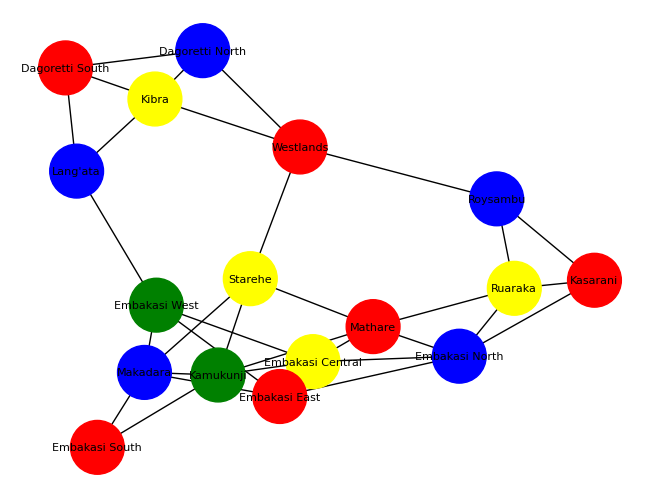

In [24]:
G = nx.Graph()

for region in sub_counties:
    G.add_node(region)

for region, nbs in neighbours.items():
    for nb in nbs:
        G.add_edge(region, nb)

pos = nx.spring_layout(G, seed=42)  # fake "map layout"

color_map = [solution[node] for node in G.nodes()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=1500,
    font_size=8,
    cmap=plt.cm.Set3
)

plt.show()